# Stochastic Multires 2K — noisy trace λ search (two pulse models)

Same **Multires 2K** training protocol on two SASE pulse datasets from `stochastic_pulses_generator_NB.ipynb`:

1. **Constant random phase** per spike (modified Formula C1)
2. **Smoothed white-noise phase** per spike (third field model)

For each dataset: train on noisy traces (SNR **0–30 dB**), λ grid **[0, 3]**, val **200** @ **15 dB**, test SNR sweep **λ*** vs **λ=0**.

**Sections:** 0 documentation · 1 train · **2a/2b** λ plots (A / B) · **3a/3b** SNR sweeps (A / B) · **4 Data C** baseline @ 0 dB · **5 Data C** trace λ search @ 0 dB · **6 Data C** trace λ search @ 30 dB · **7 Data C** test error vs λ (0 & 30 dB) · **8 Data C** SNR sweep (λ=0 vs λ=3) · **9 Data C** trace-only (Runs A & B) · **10 Data C** trace-only Run B plots

## Documentation

This notebook runs and plots the **Multires 2K noisy-trace λ-search** experiment for **two** stochastic pulse models. Results are stored in separate checkpoint folders so neither run overwrites the other.

### Experiment A — constant random phase (original)

Modified Formula C1: each pulse is a sum of **$N_{\mathrm{spikes}} = 30$** (`N_SPIKES`) Gaussian spikes; each spike has a **scalar** random phase $\theta_k \sim \mathcal{U}[-\pi,\pi]$.

- Generator: `data_generation.generate_pulses_stochastic()`
- Training script: `scripts/run_multires_2k_stochastic_noisy_trace_lambda.py`
- Artifacts: `checkpoints/benchmark/stochastic_multires_2k_noisy_trace_lambda_*`

### Experiment B — smoothed white-noise phase (updated)

Third model from `stochastic_pulses_generator_NB.ipynb`: each pulse has **$N_{\mathrm{spikes}} = 30$** (`N_SPIKES`) spikes; spike $k$ has **time-dependent** phase

$$\phi_k(t) = \mathrm{Smooth}\big[\,\xi_k(t)\,\big], \quad \xi_k(t) \sim \mathcal{N}(\theta_k,\,(0.2\pi)^2), \quad \theta_k \sim \mathcal{U}[-\pi,\pi]$$

(Gaussian smoother $\sigma = 1.6$ samples; envelope $\sigma = 2.3$ fs; $t_k \sim \mathcal{N}(0, 11\,\text{fs})$). Raw phase noise is centered on a **random offset** $\theta_k$ per spike, not on zero.

- Generator: `data_generation.generate_pulses_stochastic_smoothed_phase()`
- Training script: `scripts/run_multires_2k_stochastic_smoothed_phase_noisy_trace_lambda.py`
- Artifacts: `checkpoints/benchmark/stochastic_smoothed_phase_multires_2k_noisy_trace_lambda_*`

### Shared training protocol

2048 train / 200 val / 512 test; SNR uniform **[0, 30] dB** during training; val @ **15 dB**; $\lambda \in \{0, 0.75, 1.5, 2.25, 3\}$; early stopping (patience 25, max 200 epochs). Sections 2–3 loop over both experiments and plot each when its artifacts exist.

## Pulse models and dataset parameters

All reconstruction errors plotted in this notebook (validation L1 during λ search, test SNR sweeps for **Multires 2K** and **Multires 2K + trace**) are computed on pulses drawn from one of the two models below. Each model uses the same **time grid** and **FROG** forward model; only the spike-phase law differs.

### Shared grid and FROG

- Time samples: $N = 64$, window $T = 100\,\mathrm{fs}$, $\Delta t = T/N$.
- Central photon energy: $E_0 = 10\,\mathrm{keV}$.
- Each complex pulse $E(t)$ is turned into a clean FROG trace $I_{\mathrm{clean}}$ via the differentiable `FROGNet` ($64\times 64$). Noisy traces use AWGN at SNR $\mathrm{SNR}_{\mathrm{trace}}$ (dB):
  $$\mathrm{SNR}_{\mathrm{trace}} = 10\log_{10}\!\left(\frac{\|I_{\mathrm{clean}}\|_2^2}{\|I_{\mathrm{noise}}\|_2^2}\right).$$
- After synthesis, each pulse is **canonicalized** (`canonicalize_field`): amplitude and phase are fixed so that $|E(t{=}0)|$ is maximal and $\arg E(t{=}0)=0$ at the centre sample.

### Dataset splits (both experiments)

| Split | Count | RNG seed |
|-------|------:|---------|
| Train | 2048 | `seed` |
| Val   | 200   | `seed + 1` |
| Test  | 512   | `seed + 2` |

Default `seed = 0`. Training draws $\mathrm{SNR}_{\mathrm{trace}} \sim \mathcal{U}[0, 30]\,\mathrm{dB}$ per batch; validation and early stopping use **15 dB**. Test SNR sweeps evaluate the same 512 test pulses at $\mathrm{SNR}_{\mathrm{trace}} \in \{-10,-5,\ldots,30\}\,\mathrm{dB}$.

---

### Experiment A — constant random phase (modified Formula C1)

**Generator:** `generate_pulses_stochastic()` · `StochasticPulseConfig`

Each pulse is a sum of $N_{\mathrm{spikes}} = 30$ independent Gaussian spikes:

$$E(t) = \sum_{k=1}^{N_{\mathrm{spikes}}}
A_k\,
\exp\!\left(-\frac{(t - t_k)^2}{4\,\tau_c^2}\right)\,
e^{i\theta_k}$$

| Symbol | Meaning | Value |
|--------|---------|------:|
| $N_{\mathrm{spikes}}$ | spikes per pulse (`N_SPIKES`) | 30 |
| $\tau_c$ | coherence time | $2.5\,\mathrm{fs}$ |
| $t_k$ | spike centre | $\mathcal{N}(0,\,5.73\,\mathrm{fs})$ |
| $A_k$ | spike amplitude | $\mathcal{U}[0.75,\,1.0]$ |
| $\theta_k$ | constant phase | $\mathcal{U}[-\pi,\,\pi]$ |

*(The linear frequency-phase term of Formula C1 is omitted; $\Delta\omega_k$ is not applied in the time-domain phase.)*

---

### Experiment B — smoothed white-noise phase

**Generator:** `generate_pulses_stochastic_smoothed_phase()` · `SmoothedPhaseStochasticPulseConfig`

Same Gaussian envelope as above, but spike $k$ carries a **time-dependent** phase curve:

$$E(t) = \sum_{k=1}^{N_{\mathrm{spikes}}}
A_k\,
\exp\!\left(-\frac{(t - t_k)^2}{4\,\tau_c^2}\right)\,
\exp\!\bigl(i\,\phi_k(t)\bigr)$$

$$\phi_k(t) = \mathrm{Smooth}_\sigma\!\bigl[\,\xi_k(t)\,\bigr],
\qquad
\xi_k(t) \sim \mathcal{N}\!\bigl(\theta_k,\,\sigma_\phi^2\bigr),
\qquad
\theta_k \sim \mathcal{U}[-\pi,\,\pi]$$

| Symbol | Meaning | Value |
|--------|---------|------:|
| $N_{\mathrm{spikes}}$ | spikes per pulse (`N_SPIKES`) | 30 |
| $\tau_c$ | coherence time | $2.3\,\mathrm{fs}$ |
| $t_k$ | spike centre | $\mathcal{N}(0,\,11\,\mathrm{fs})$ |
| $A_k$ | spike amplitude | $\mathcal{U}[0.75,\,1.0]$ |
| $\sigma_\phi$ | raw phase noise std | $0.2\pi$ rad |
| $\sigma$ | Gaussian smoother width | $1.6$ samples (`scipy.ndimage.gaussian_filter`) |

Section 3 may plot **Multires 2K + trace** at a manually chosen $\lambda$ (e.g. $\lambda = 0.75$ via `LAMBDA_TRACE_OVERRIDE`); the **test pulses** are unchanged.

---

### Reconstruction error metrics (test SNR sweeps)

On each noisy test trace, the CNN predicts packed $\hat{E}$. Errors are averaged over 512 pulses:

- **L1 (best ambiguity):** $\min_{g\in\{\mathrm{id},\,\mathrm{conj},\,\mathrm{flip},\,\mathrm{shift}\}} \|\hat{E}_g - E\|_1 / N$.
- **SIMILARITY_ERROR (best ambiguity):** $1 - \cos\!\bigl(\delta E\bigr)$ with $\delta E = \arccos\!\bigl(|\langle \hat{E}, E\rangle| / (\|\hat{E}\|\|E\|)\bigr)$, minimized over the same ambiguities.

These metrics characterize recovery of the **same stochastic $E(t)$** defined above—not unwrapped phase used only for visualization in `stochastic_pulses_generator_NB.ipynb`.


In [34]:
import json
import os
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch

os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")

SRC = Path.cwd()
if not (SRC / "train.py").exists():
    SRC = SRC.parent
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from evaluate_cnn import load_cnn_sweep, plot_metric_curves
from pulse_metrics import snr_db_to_equivalent_n_pulses

SEED = 0
N_TRAIN = 2048
N_VAL = 200
N_TEST = 512
TRAIN_SNR_DB_RANGE = (0.0, 30.0)
VAL_SNR_DB = 15.0
LAMBDA_GRID = np.linspace(0.0, 3.0, 5)
MAX_EPOCHS = 200
PATIENCE = 25
SNR_SWEEP_DB = np.arange(-10.0, 31.0, 5.0)

BENCH = SRC / "checkpoints/benchmark"

EXPERIMENTS = {
    "constant_phase": {
        "label": "Constant random phase",
        "short": "constant-phase",
        "results_npz": BENCH / "stochastic_multires_2k_noisy_trace_lambda.npz",
        "meta_json": BENCH / "stochastic_multires_2k_noisy_trace_lambda_meta.json",
        "opt_sweep": BENCH / "stochastic_multires_2k_noisy_trace_lambda_opt_sweep.npz",
        "baseline_sweep": BENCH / "stochastic_multires_2k_noisy_trace_lambda_baseline_sweep.npz",
        "train_script": SRC / "scripts/run_multires_2k_stochastic_noisy_trace_lambda.py",
    },
    "smoothed_phase": {
        "label": "Smoothed white-noise phase",
        "short": "smoothed-phase",
        "results_npz": BENCH / "stochastic_smoothed_phase_multires_2k_noisy_trace_lambda.npz",
        "meta_json": BENCH / "stochastic_smoothed_phase_multires_2k_noisy_trace_lambda_meta.json",
        "opt_sweep": BENCH / "stochastic_smoothed_phase_multires_2k_noisy_trace_lambda_lam075_sweep.npz",
        "baseline_sweep": BENCH / "stochastic_smoothed_phase_multires_2k_noisy_trace_lambda_baseline_sweep.npz",
        "train_script": SRC / "scripts/run_multires_2k_stochastic_smoothed_phase_noisy_trace_lambda.py",
        "lam_sweep_script": SRC / "scripts/run_stochastic_smoothed_phase_lam_sweep.py",
    },
}

# Optional manual λ for trace model in Section 3 (None = auto argmin val L1)
LAMBDA_TRACE_OVERRIDE = {"smoothed_phase": 0.75}

# Per-experiment training toggles (set True to (re)train that dataset only)
RUN_TRAINING = {
    "constant_phase": False,
    "smoothed_phase": False,
}
FORCE_RETRAIN = False

experiment_summaries = {}

## 1. Train λ grid + SNR sweeps (both pulse models)

Runs each enabled experiment in `RUN_TRAINING`. Existing artifacts are loaded for plotting even when training is skipped.

In [35]:
for exp_key, exp in EXPERIMENTS.items():
    print(f"\n=== {exp['label']} ({exp_key}) ===")

    if RUN_TRAINING.get(exp_key, False):
        cmd = [
            sys.executable,
            str(exp["train_script"]),
            "--seed", str(SEED),
            "--n-train", str(N_TRAIN),
            "--n-val", str(N_VAL),
            "--n-test", str(N_TEST),
            "--max-epochs", str(MAX_EPOCHS),
            "--patience", str(PATIENCE),
            "--train-snr-min", str(TRAIN_SNR_DB_RANGE[0]),
            "--train-snr-max", str(TRAIN_SNR_DB_RANGE[1]),
            "--val-snr-db", str(VAL_SNR_DB),
            "--lambda-min", "0",
            "--lambda-max", "3",
            "--lambda-steps", "5",
        ]
        if FORCE_RETRAIN:
            cmd.append("--force")
        elif exp["results_npz"].exists():
            cmd.append("--resume")
        print("Running:", " ".join(cmd))
        proc = subprocess.run(cmd, cwd=str(SRC))
        if proc.returncode != 0:
            raise RuntimeError(f"training failed for {exp_key} (exit {proc.returncode})")
    else:
        print("RUN_TRAINING=False — skipping training, will load existing artifacts if present.")

    if not exp["results_npz"].exists():
        print(f"  No results yet: {exp['results_npz']}")
        continue

    assert exp["meta_json"].exists(), f"Missing {exp['meta_json']}"
    d = np.load(exp["results_npz"])
    summary = {
        "lambda_opt": float(d["lambda_opt"]),
        "lambda_baseline": float(d["lambda_baseline"]),
        "best_val_at_opt": float(d["best_val_at_opt"]),
        "best_val_at_baseline": float(d["best_val_at_baseline"]),
        "trace_scale": float(d["trace_scale"]),
    }
    experiment_summaries[exp_key] = summary
    print(
        f"  lambda* = {summary['lambda_opt']:.4f}  "
        f"best val L1 = {summary['best_val_at_opt']:.5f}"
    )
    print(
        f"  baseline lambda = {summary['lambda_baseline']:.4f}  "
        f"best val L1 = {summary['best_val_at_baseline']:.5f}"
    )
    print(f"  trace_scale = {summary['trace_scale']:.4f}")


=== Constant random phase (constant_phase) ===
RUN_TRAINING=False — skipping training, will load existing artifacts if present.
  lambda* = 1.5000  best val L1 = 2.53321
  baseline lambda = 0.0000  best val L1 = 2.63901
  trace_scale = 8.1582

=== Smoothed white-noise phase (smoothed_phase) ===
RUN_TRAINING=False — skipping training, will load existing artifacts if present.
  lambda* = 0.0000  best val L1 = 5.05632
  baseline lambda = 0.0000  best val L1 = 5.05632
  trace_scale = 7.5697


## 2. λ optimization — val L1 vs λ and training curves

In [36]:
def plot_lambda_search(exp):
    with open(exp["meta_json"], encoding="utf-8") as f:
        run_log = json.load(f)

    lambda_grid = np.array([e["lam"] for e in run_log], dtype=np.float64)
    best_val = np.array([e["best_val_l1"] for e in run_log], dtype=np.float64)
    lambda_opt = float(lambda_grid[int(np.argmin(best_val))])

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(lambda_grid, best_val, "o-", lw=2, ms=8)
    ax.axvline(lambda_opt, color="C3", ls="--", lw=1.5, label=f"lambda* = {lambda_opt:.2f}")
    ax.set_xlabel("lambda (trace loss weight)")
    ax.set_ylabel(f"best val pulse L1 @ {VAL_SNR_DB:.0f} dB")
    ax.set_title(f"lambda search — {exp['label']} (n_val={N_VAL})")
    ax.legend()
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    plt.show()

    print(f"Per-lambda summary ({exp['short']}):")
    for e in run_log:
        print(
            f"  lambda={e['lam']:.4f}  best_epoch={e['best_epoch']:3d}  "
            f"stopped={e['stopped_epoch']:3d}  best_val_L1={e['best_val_l1']:.5f}"
        )

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for e in run_log:
        ep = np.arange(1, len(e["val_l1_pulses"]) + 1)
        axes[0].plot(ep, e["train_losses"], label=f"lambda={e['lam']:.2g}")
        axes[1].plot(ep, e["val_l1_pulses"], label=f"lambda={e['lam']:.2g}")
    axes[0].set_xlabel("epoch")
    axes[0].set_ylabel("train loss")
    axes[0].set_title(f"Train loss — {exp['short']}")
    axes[1].set_xlabel("epoch")
    axes[1].set_ylabel(f"val L1 @ {VAL_SNR_DB:.0f} dB")
    axes[1].set_title(f"Val L1 — {exp['short']}")
    for ax in axes:
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
    fig.tight_layout()
    plt.show()

    return lambda_opt
def collect_data_c_trace_test_evals(eval_opt_path, lam_evals):
    """Build full lambda grid arrays from lambda*=0 eval + per-lambda npz files."""
    eval_opt = np.load(eval_opt_path)
    lam = [0.0]
    l1_m = [float(eval_opt["l1_amb_mean"])]
    l1_s = [float(eval_opt["l1_amb_std"])]
    sim_m = [float(eval_opt["sim_amb_mean"])]
    sim_s = [float(eval_opt["sim_amb_std"])]
    for lam_val, _, eval_name in lam_evals:
        e = np.load(BENCH / eval_name)
        lam.append(float(lam_val))
        l1_m.append(float(e["l1_amb_mean"]))
        l1_s.append(float(e["l1_amb_std"]))
        sim_m.append(float(e["sim_amb_mean"]))
        sim_s.append(float(e["sim_amb_std"]))
    return (
        np.array(lam, dtype=np.float64),
        np.array(l1_m, dtype=np.float64),
        np.array(l1_s, dtype=np.float64),
        np.array(sim_m, dtype=np.float64),
        np.array(sim_s, dtype=np.float64),
    )


def plot_data_c_test_errors_vs_lambda(
    test_snr_db,
    eval_opt_path,
    lam_evals,
    *,
    lambda_opt=None,
    n_test=512,
):
    """Plot best-ambiguity L1 and SIMILARITY_ERROR vs lambda at fixed test SNR."""
    lam, l1_m, l1_s, sim_m, sim_s = collect_data_c_trace_test_evals(eval_opt_path, lam_evals)
    if lambda_opt is None:
        lambda_opt = float(lam[int(np.argmin(l1_m))])

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for ax, y_m, y_s, ylabel in (
        (axes[0], l1_m, l1_s, "L1 (best ambiguity)"),
        (axes[1], sim_m, sim_s, "SIMILARITY_ERROR (best amb)"),
    ):
        ax.errorbar(lam, y_m, yerr=y_s, fmt="o-", lw=2, ms=8, capsize=4)
        ax.axvline(lambda_opt, color="C3", ls="--", lw=1.5, label=f"lambda* = {lambda_opt:.2f}")
        ax.set_xlabel("lambda (trace loss weight)")
        ax.set_ylabel(ylabel)
        ax.set_title(f"{ylabel} vs lambda — test @ {test_snr_db:.0f} dB SNR (n={n_test})")
        ax.legend()
        ax.grid(True, alpha=0.3)
    fig.suptitle("Data C — Multires 2K + trace loss", y=1.02)
    fig.tight_layout()
    plt.show()


### Experiment A — constant random phase

λ search, per-λ training loss, and validation L1 curves for **modified Formula C1** pulses (`constant_phase`).

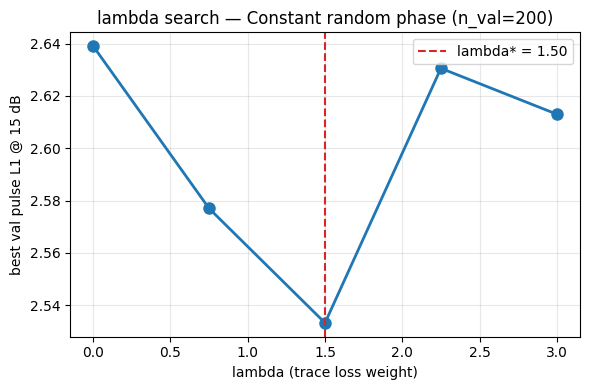

Per-lambda summary (constant-phase):
  lambda=0.0000  best_epoch= 32  stopped= 57  best_val_L1=2.63901
  lambda=0.7500  best_epoch= 66  stopped= 91  best_val_L1=2.57695
  lambda=1.5000  best_epoch=120  stopped=145  best_val_L1=2.53321
  lambda=2.2500  best_epoch= 77  stopped=102  best_val_L1=2.63055
  lambda=3.0000  best_epoch=178  stopped=200  best_val_L1=2.61300


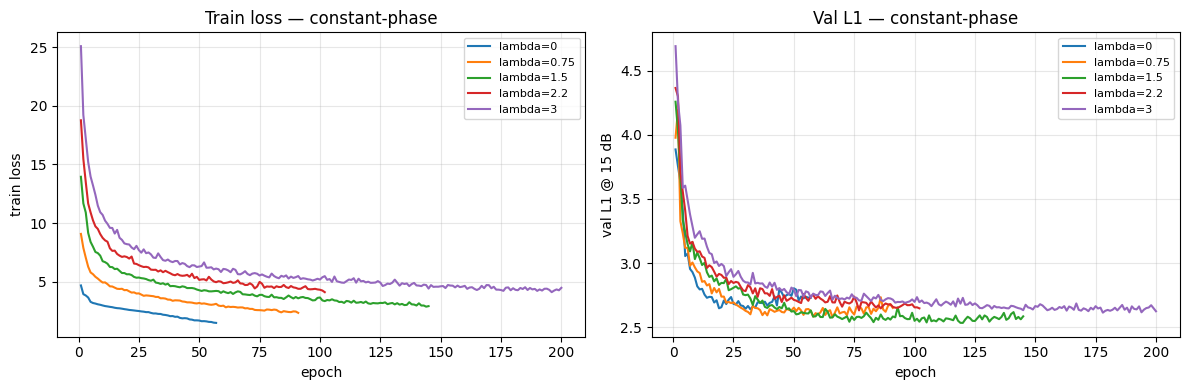

In [37]:
_exp_a = EXPERIMENTS["constant_phase"]
if not _exp_a["meta_json"].exists():
    print(f"Skipping {_exp_a['label']}: missing {_exp_a['meta_json']}")
else:
    plot_lambda_search(_exp_a)

### Experiment B — smoothed white-noise phase

λ search, per-λ training loss, and validation L1 curves for **smoothed-phase** SASE pulses (`smoothed_phase`).

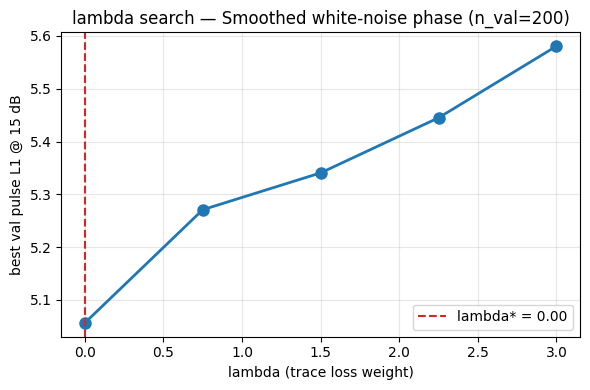

Per-lambda summary (smoothed-phase):
  lambda=0.0000  best_epoch= 20  stopped= 45  best_val_L1=5.05632
  lambda=0.7500  best_epoch= 27  stopped= 52  best_val_L1=5.27075
  lambda=1.5000  best_epoch= 55  stopped= 80  best_val_L1=5.34054
  lambda=2.2500  best_epoch= 34  stopped= 59  best_val_L1=5.44491
  lambda=3.0000  best_epoch= 46  stopped= 71  best_val_L1=5.58063


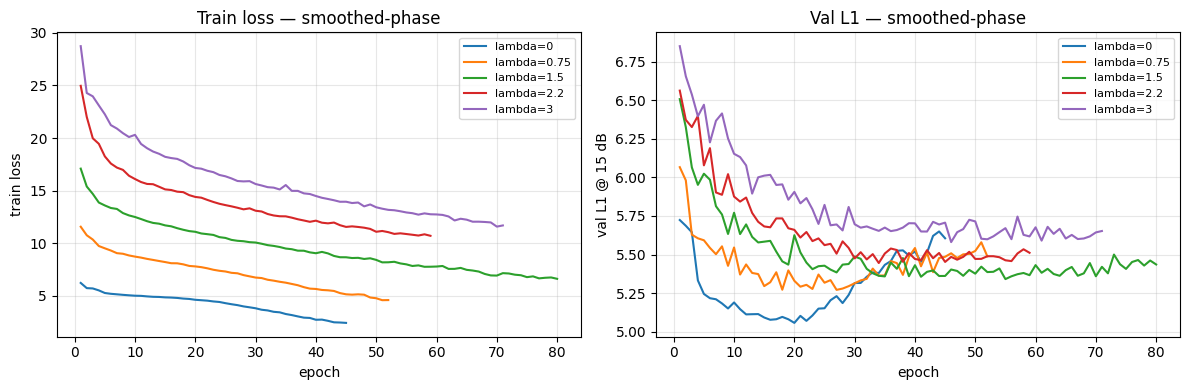

In [38]:
_exp_b = EXPERIMENTS["smoothed_phase"]
if not _exp_b["meta_json"].exists():
    print(f"Skipping {_exp_b['label']}: missing {_exp_b['meta_json']}")
else:
    plot_lambda_search(_exp_b)

## 3. Test SNR sweep — L1 and SIMILARITY_ERROR

In [39]:
def plot_snr_sweeps(exp, lambda_trace):
    if not exp["opt_sweep"].exists() or not exp["baseline_sweep"].exists():
        print(f"Skipping SNR sweeps for {exp['label']}: missing sweep files")
        return

    sweep_opt = load_cnn_sweep(exp["opt_sweep"])
    sweep_base = load_cnn_sweep(exp["baseline_sweep"])
    sweep_opt.experiment_name = f"{exp['short']}: Multires 2K + trace (λ={lambda_trace:.2g})"
    sweep_base.experiment_name = f"{exp['short']}: Multires 2K (lambda=0)"

    curves = [sweep_base, sweep_opt]
    snr = sweep_opt.snr_sweep_db
    fmts = ["--^", "-s"]
    tag = f"{exp['short']} test n={N_TEST}"

    def _plot_snr_metric(attr_m, attr_s, ylabel, title_suffix):
        series = [
            (getattr(r, attr_m), getattr(r, attr_s), fmts[i], r.experiment_name)
            for i, r in enumerate(curves)
        ]
        plot_metric_curves(
            snr,
            series,
            xlabel="trace SNR (dB)",
            ylabel=ylabel,
            title=f"{ylabel} vs trace SNR — {title_suffix} ({tag})",
        )
        n_equiv = np.array([snr_db_to_equivalent_n_pulses(float(s)) for s in snr])
        plot_metric_curves(
            n_equiv,
            series,
            xlabel="equivalent pulse count N (log scale)",
            ylabel=ylabel,
            title=f"{ylabel} vs N — {title_suffix} ({tag})",
            xscale="log",
        )

    _plot_snr_metric(
        "cnn_l1_amb_m",
        "cnn_l1_amb_s",
        "L1 (best ambiguity, mean ± std)",
        "best L1 ambiguity",
    )
    _plot_snr_metric(
        "cnn_sim_amb_m",
        "cnn_sim_amb_s",
        "SIMILARITY_ERROR (best ambiguity)",
        "best ambiguity",
    )


def _resolve_lambda_trace(exp_key, exp):
    with open(exp["meta_json"], encoding="utf-8") as f:
        run_log = json.load(f)
    best_val = np.array([e["best_val_l1"] for e in run_log], dtype=np.float64)
    lam_grid = np.array([e["lam"] for e in run_log], dtype=np.float64)
    lambda_auto = float(lam_grid[int(np.argmin(best_val))])
    lambda_trace = float(LAMBDA_TRACE_OVERRIDE.get(exp_key, lambda_auto))
    if lambda_trace != lambda_auto:
        print(f"  using λ={lambda_trace:.2g} (override; auto λ*={lambda_auto:.2g})")
    return lambda_trace


### Experiment A — constant random phase

Test-set SNR sweep (**Multires 2K**, λ=0) vs **Multires 2K + trace** (λ* from val L1).

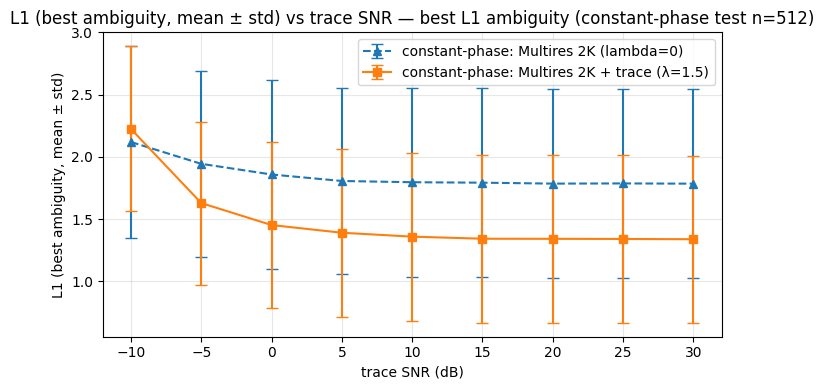

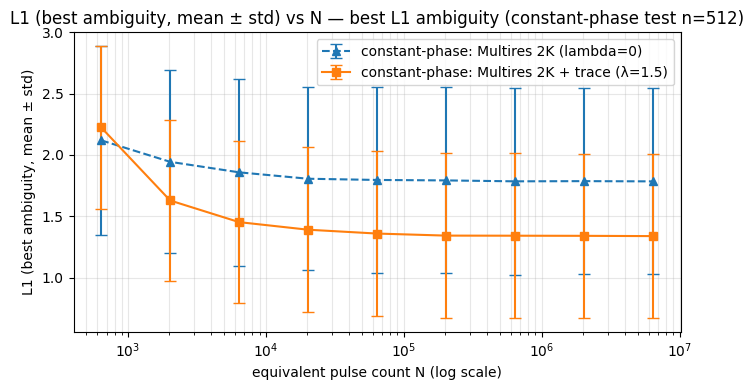

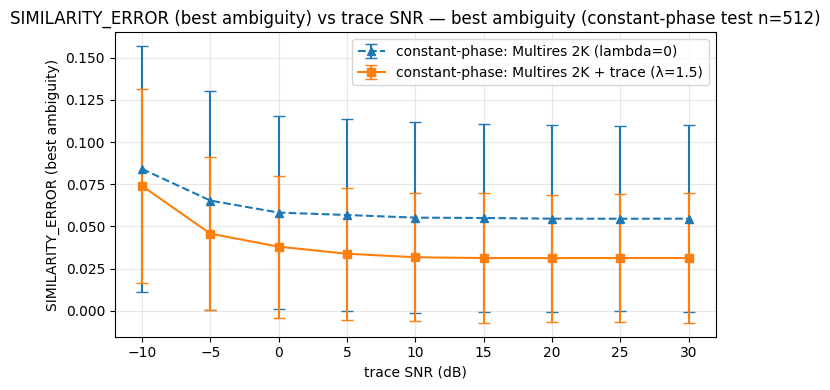

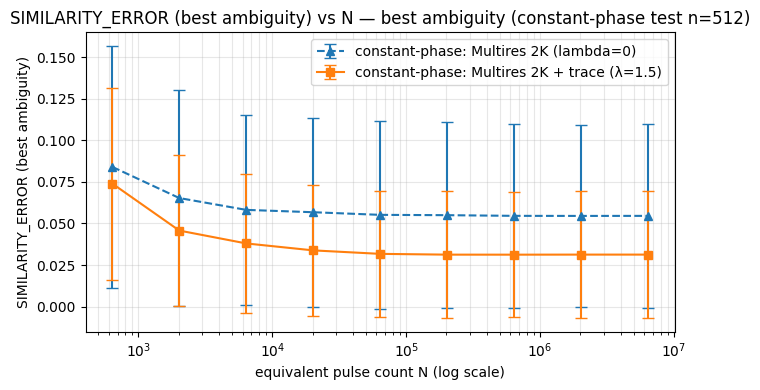

In [40]:
_exp_a = EXPERIMENTS["constant_phase"]
if not _exp_a["meta_json"].exists():
    print(f"Skipping {_exp_a['label']}: missing meta")
else:
    plot_snr_sweeps(_exp_a, _resolve_lambda_trace("constant_phase", _exp_a))

### Experiment B — smoothed white-noise phase

Test-set SNR sweep (**Multires 2K**, λ=0) vs **Multires 2K + trace** (λ from `LAMBDA_TRACE_OVERRIDE` or λ*).

  using λ=0.75 (override; auto λ*=0)


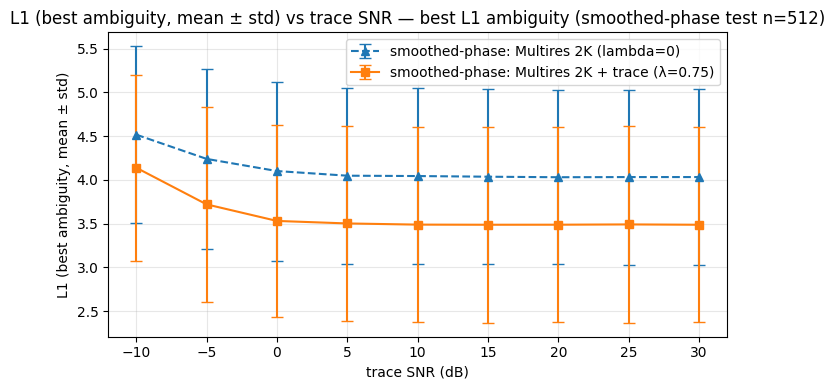

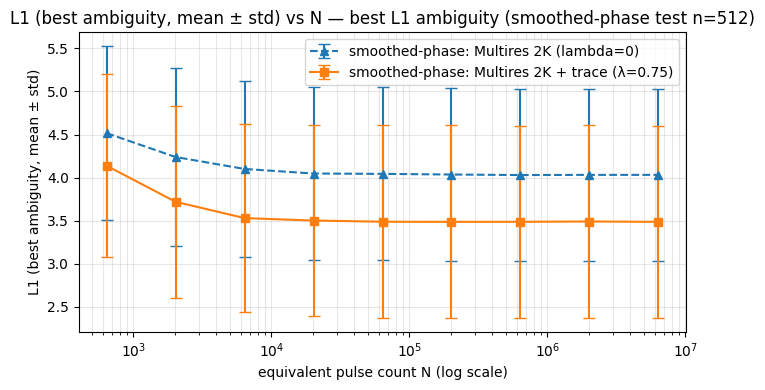

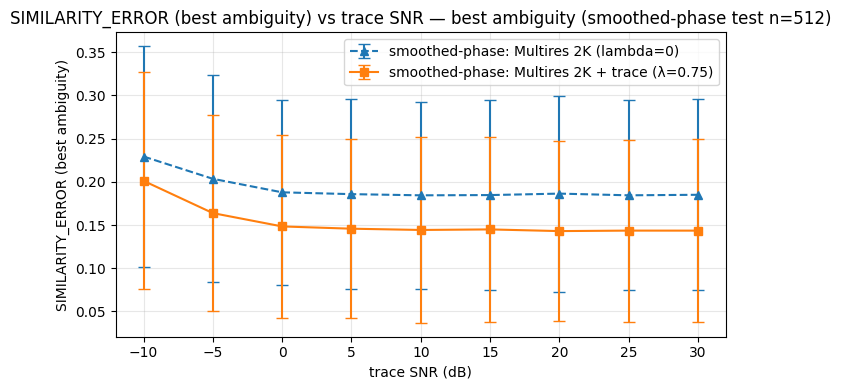

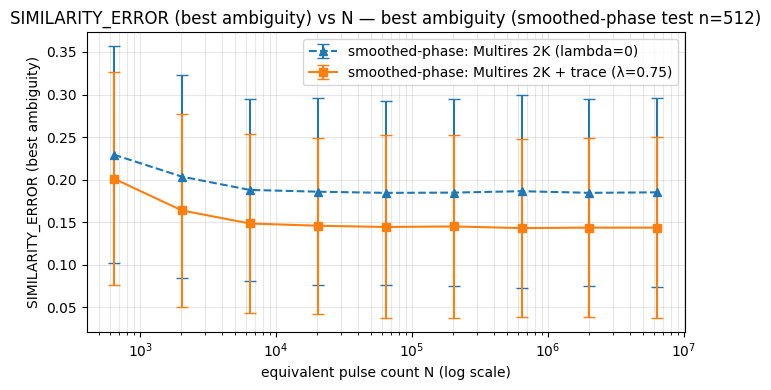

In [41]:
_exp_b = EXPERIMENTS["smoothed_phase"]
if not _exp_b["meta_json"].exists():
    print(f"Skipping {_exp_b['label']}: missing meta")
else:
    plot_snr_sweeps(_exp_b, _resolve_lambda_trace("smoothed_phase", _exp_b))

---

## 4. Data C — Multires 2K baseline @ test SNR = 0 dB

**Isolated experiment** (not part of Experiments A/B above).

**Data C:** modified Formula C1 stochastic pulses (same as Experiment A) with wider spike-centre spread: $t_k \sim \mathcal{N}(0,\,9.5\,\mathrm{fs})$ instead of $5.73\,\mathrm{fs}$; all other pulse parameters match Experiment A ($N_{\mathrm{spikes}}=30$, $\tau_c=2.5\,\mathrm{fs}$, etc.).

**Model:** **Multires 2K only** — pulse L1 loss, **no trace term** ($\lambda=0$).

**Training** (same protocol as Experiment A, $\lambda=0$ run): 2048 train / 200 val / 512 test; AWGN on traces with $\mathrm{SNR}_{\mathrm{trace}} \sim \mathcal{U}[0, 30]\,\mathrm{dB}$; validation and early stopping on **val pulse L1 @ 15 dB** (patience 25, max 200 epochs).

**Evaluation:** test-set reconstruction error at **0 dB trace SNR only** (best-ambiguity L1 and SIMILARITY_ERROR).

In [42]:
RUN_DATA_C_TRAIN = False
FORCE_DATA_C_RETRAIN = False

DATA_C_CKPT = BENCH / "stochastic_data_c_multires_2k_baseline.pt"
DATA_C_META = BENCH / "stochastic_data_c_multires_2k_baseline_meta.json"
DATA_C_EVAL_0DB = BENCH / "stochastic_data_c_multires_2k_baseline_test_0db.npz"
DATA_C_SCRIPT = SRC / "scripts/run_multires_2k_stochastic_data_c_baseline.py"

if RUN_DATA_C_TRAIN:
    cmd = [
        sys.executable,
        str(DATA_C_SCRIPT),
        "--seed", str(SEED),
        "--n-train", str(N_TRAIN),
        "--n-val", str(N_VAL),
        "--n-test", str(N_TEST),
        "--max-epochs", str(MAX_EPOCHS),
        "--patience", str(PATIENCE),
        "--train-snr-min", str(TRAIN_SNR_DB_RANGE[0]),
        "--train-snr-max", str(TRAIN_SNR_DB_RANGE[1]),
        "--val-snr-db", str(VAL_SNR_DB),
        "--test-snr-db", "0.0",
    ]
    if FORCE_DATA_C_RETRAIN:
        cmd.append("--force")
    print("Running:", " ".join(cmd))
    proc = subprocess.run(cmd, cwd=str(SRC))
    if proc.returncode != 0:
        raise RuntimeError(f"Data C training failed (exit {proc.returncode})")

assert DATA_C_CKPT.exists(), f"Missing {DATA_C_CKPT} — set RUN_DATA_C_TRAIN=True"
assert DATA_C_EVAL_0DB.exists(), f"Missing {DATA_C_EVAL_0DB}"

Data C — Multires 2K (λ=0, no trace loss)
  t_center_std = 9.50 fs
  best_epoch = 21  best_val_L1@15dB = 4.0577

Test @ 0 dB SNR  (n=512)
  L1 (best ambiguity)        = 3.0992 ± 0.9248
  SIMILARITY_ERROR (best amb) = 0.1189 ± 0.0837


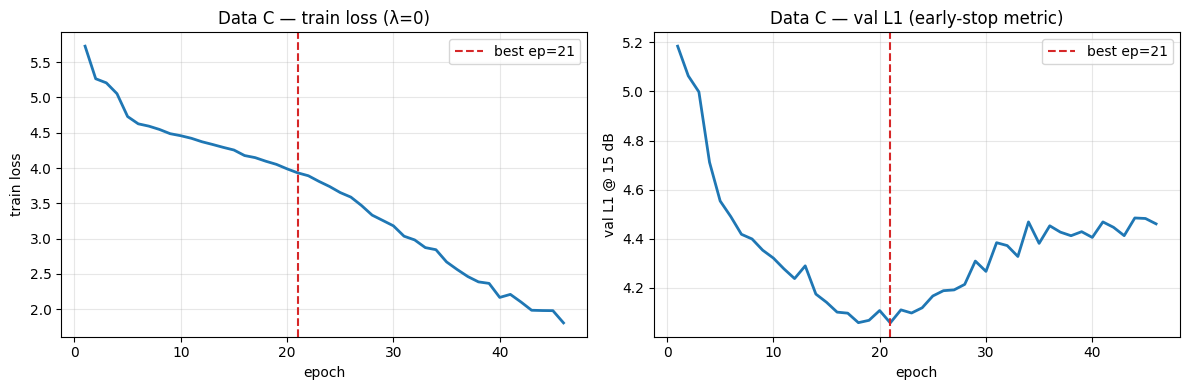

In [43]:
eval0 = np.load(DATA_C_EVAL_0DB)
meta0 = json.loads(DATA_C_META.read_text(encoding="utf-8"))
ckpt0 = torch.load(DATA_C_CKPT, map_location="cpu", weights_only=False)

print("Data C — Multires 2K (λ=0, no trace loss)")
print(f"  t_center_std = {float(eval0['t_center_std_fs']):.2f} fs")
print(f"  best_epoch = {int(eval0['best_epoch'])}  best_val_L1@15dB = {float(eval0['best_val_l1']):.4f}")
print(f"\nTest @ {float(eval0['test_snr_db']):.0f} dB SNR  (n={int(eval0['n_test'])})")
print(f"  L1 (best ambiguity)        = {float(eval0['l1_amb_mean']):.4f} ± {float(eval0['l1_amb_std']):.4f}")
print(f"  SIMILARITY_ERROR (best amb) = {float(eval0['sim_amb_mean']):.4f} ± {float(eval0['sim_amb_std']):.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ep = np.arange(1, len(ckpt0["train_losses"]) + 1)
axes[0].plot(ep, ckpt0["train_losses"], lw=2)
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("train loss")
axes[0].set_title("Data C — train loss (λ=0)")
axes[0].axvline(int(ckpt0["best_epoch"]), color="C3", ls="--", label=f"best ep={int(ckpt0['best_epoch'])}")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(ep, ckpt0["val_l1_pulses"], lw=2)
axes[1].set_xlabel("epoch")
axes[1].set_ylabel(f"val L1 @ {VAL_SNR_DB:.0f} dB")
axes[1].set_title("Data C — val L1 (early-stop metric)")
axes[1].axvline(int(ckpt0["best_epoch"]), color="C3", ls="--", label=f"best ep={int(ckpt0['best_epoch'])}")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

## 5. Data C — Multires 2K + trace loss (λ search) @ test SNR = 0 dB

**Data C** (same as Section 4). **Model:** Multires 2K with **trace L1** in the training loss:

$$\mathcal{L} = \mathrm{L1}_{\mathrm{pulse}} + \lambda \cdot (\mathrm{L1}_{\mathrm{trace}} / s_{\mathrm{trace}})$$

Same protocol as **Experiment A**: $\lambda \in \{0, 0.75, 1.5, 2.25, 3\}$, val pulse L1 @ **15 dB**, early stopping (patience 25). Select **λ\*** = argmin best val L1; report test errors at **0 dB SNR** for **λ\*** and for each $\lambda$ in the grid.

In [44]:
RUN_DATA_C_TRACE_TRAIN = False
FORCE_DATA_C_TRACE_RETRAIN = False

DATA_C_TRACE_RESULTS = BENCH / "stochastic_data_c_multires_2k_noisy_trace_lambda.npz"
DATA_C_TRACE_META = BENCH / "stochastic_data_c_multires_2k_noisy_trace_lambda_meta.json"
DATA_C_TRACE_EVAL_0DB = BENCH / "stochastic_data_c_multires_2k_trace_test_0db.npz"
DATA_C_TRACE_SCRIPT = SRC / "scripts/run_multires_2k_stochastic_data_c_noisy_trace_lambda.py"

DATA_C_TRACE_EXP = {
    "label": "Data C — constant random phase (t_center_std=9.5 fs)",
    "short": "data-c",
    "results_npz": DATA_C_TRACE_RESULTS,
    "meta_json": DATA_C_TRACE_META,
}

DATA_C_TRACE_CKPT_DIR = BENCH / "stochastic_data_c_multires_2k_noisy_trace_lambda"
DATA_C_TRACE_LAM_EVALS = [
    (0.75, "lam_0.7500.pt", "stochastic_data_c_multires_2k_trace_lam075_test_0db.npz"),
    (1.5, "lam_1.5000.pt", "stochastic_data_c_multires_2k_trace_lam150_test_0db.npz"),
    (2.25, "lam_2.2500.pt", "stochastic_data_c_multires_2k_trace_lam225_test_0db.npz"),
    (3.0, "lam_3.0000.pt", "stochastic_data_c_multires_2k_trace_lam300_test_0db.npz"),
]

if RUN_DATA_C_TRACE_TRAIN:
    cmd = [
        sys.executable,
        str(DATA_C_TRACE_SCRIPT),
        "--seed", str(SEED),
        "--n-train", str(N_TRAIN),
        "--n-val", str(N_VAL),
        "--n-test", str(N_TEST),
        "--max-epochs", str(MAX_EPOCHS),
        "--patience", str(PATIENCE),
        "--train-snr-min", str(TRAIN_SNR_DB_RANGE[0]),
        "--train-snr-max", str(TRAIN_SNR_DB_RANGE[1]),
        "--val-snr-db", str(VAL_SNR_DB),
        "--lambda-min", "0",
        "--lambda-max", "3",
        "--lambda-steps", "5",
        "--test-snr-db", "0.0",
    ]
    if FORCE_DATA_C_TRACE_RETRAIN:
        cmd.append("--force")
    elif DATA_C_TRACE_RESULTS.exists():
        cmd.append("--resume")
    print("Running:", " ".join(cmd))
    proc = subprocess.run(cmd, cwd=str(SRC))
    if proc.returncode != 0:
        raise RuntimeError(f"Data C trace training failed (exit {proc.returncode})")

assert DATA_C_TRACE_RESULTS.exists(), f"Missing {DATA_C_TRACE_RESULTS} — set RUN_DATA_C_TRACE_TRAIN=True"
assert DATA_C_TRACE_META.exists(), f"Missing {DATA_C_TRACE_META}"
assert DATA_C_TRACE_EVAL_0DB.exists(), f"Missing {DATA_C_TRACE_EVAL_0DB}"
for lam_val, ckpt_name, eval_name in DATA_C_TRACE_LAM_EVALS:
    assert (DATA_C_TRACE_CKPT_DIR / ckpt_name).exists(), f"Missing {DATA_C_TRACE_CKPT_DIR / ckpt_name}"
    assert (BENCH / eval_name).exists(), f"Missing {BENCH / eval_name}"

Data C — Multires 2K + trace loss (λ search, same protocol as Experiment A)
  t_center_std = 9.50 fs
  trace_scale = 7.7260
  lambda* = 0.0000  best val L1@15dB = 4.02811
  baseline lambda = 0.0000  best val L1 = 4.02811


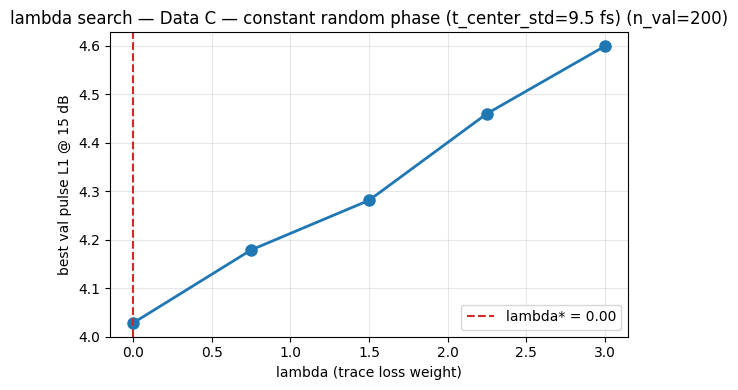

Per-lambda summary (data-c):
  lambda=0.0000  best_epoch= 21  stopped= 46  best_val_L1=4.02811
  lambda=0.7500  best_epoch= 33  stopped= 58  best_val_L1=4.17869
  lambda=1.5000  best_epoch= 60  stopped= 85  best_val_L1=4.28112
  lambda=2.2500  best_epoch= 97  stopped=122  best_val_L1=4.46000
  lambda=3.0000  best_epoch= 82  stopped=107  best_val_L1=4.59920


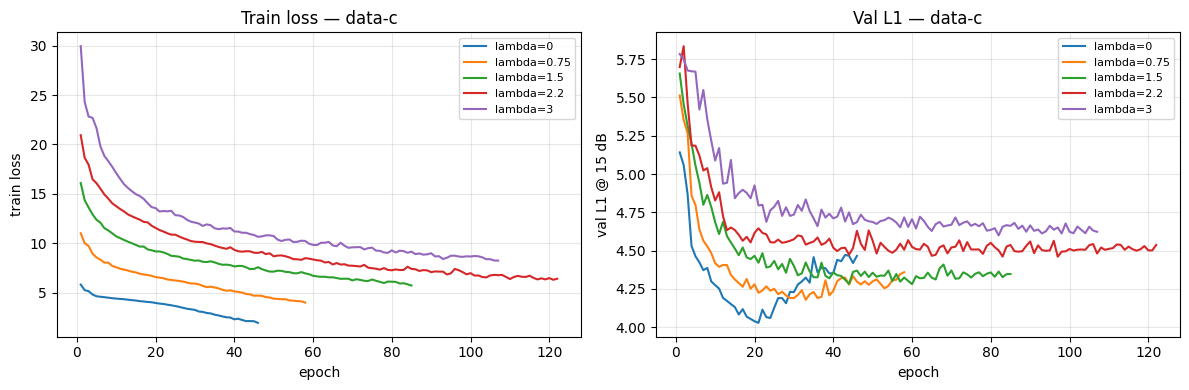


Test @ 0 dB SNR  (n=512)

  λ* = 0.0000  (best val L1 @ 15 dB = 4.02811)
    L1 (best ambiguity)        = 3.1568 ± 0.9704
    SIMILARITY_ERROR (best amb) = 0.1261 ± 0.0964

  λ = 0.75  (best_epoch=33, best val L1 @ 15 dB = 4.17869)
    L1 (best ambiguity)        = 2.6982 ± 0.9789
    SIMILARITY_ERROR (best amb) = 0.0946 ± 0.0834

  λ = 1.50  (best_epoch=60, best val L1 @ 15 dB = 4.28112)
    L1 (best ambiguity)        = 2.6341 ± 0.9946
    SIMILARITY_ERROR (best amb) = 0.0887 ± 0.0870

  λ = 2.25  (best_epoch=97, best val L1 @ 15 dB = 4.46000)
    L1 (best ambiguity)        = 2.5697 ± 0.9362
    SIMILARITY_ERROR (best amb) = 0.0825 ± 0.0787

  λ = 3.00  (best_epoch=82, best val L1 @ 15 dB = 4.59920)
    L1 (best ambiguity)        = 2.5378 ± 0.9652
    SIMILARITY_ERROR (best amb) = 0.0761 ± 0.0660


In [45]:
d_trace = np.load(DATA_C_TRACE_RESULTS)
lambda_opt_c = float(d_trace["lambda_opt"])
trace_scale_c = float(d_trace["trace_scale"])

print("Data C — Multires 2K + trace loss (λ search, same protocol as Experiment A)")
print(f"  t_center_std = {float(d_trace['t_center_std_fs']):.2f} fs")
print(f"  trace_scale = {trace_scale_c:.4f}")
print(
    f"  lambda* = {lambda_opt_c:.4f}  "
    f"best val L1@15dB = {float(d_trace['best_val_at_opt']):.5f}"
)
print(
    f"  baseline lambda = {float(d_trace['lambda_baseline']):.4f}  "
    f"best val L1 = {float(d_trace['best_val_at_baseline']):.5f}"
)

lambda_opt_c = plot_lambda_search(DATA_C_TRACE_EXP)

eval_trace = np.load(DATA_C_TRACE_EVAL_0DB)

print(f"\nTest @ {float(eval_trace['test_snr_db']):.0f} dB SNR  (n={int(eval_trace['n_test'])})")
print(f"\n  λ* = {lambda_opt_c:.4f}  (best val L1 @ 15 dB = {float(d_trace['best_val_at_opt']):.5f})")
print(f"    L1 (best ambiguity)        = {float(eval_trace['l1_amb_mean']):.4f} ± {float(eval_trace['l1_amb_std']):.4f}")
print(f"    SIMILARITY_ERROR (best amb) = {float(eval_trace['sim_amb_mean']):.4f} ± {float(eval_trace['sim_amb_std']):.4f}")

for lam_val, ckpt_name, eval_name in DATA_C_TRACE_LAM_EVALS:
    eval_lam = np.load(BENCH / eval_name)
    ckpt_lam = torch.load(DATA_C_TRACE_CKPT_DIR / ckpt_name, map_location="cpu", weights_only=False)
    print(f"\n  λ = {lam_val:.2f}  (best_epoch={int(ckpt_lam['best_epoch'])}, best val L1 @ 15 dB = {float(ckpt_lam['best_val_l1']):.5f})")
    print(f"    L1 (best ambiguity)        = {float(eval_lam['l1_amb_mean']):.4f} ± {float(eval_lam['l1_amb_std']):.4f}")
    print(f"    SIMILARITY_ERROR (best amb) = {float(eval_lam['sim_amb_mean']):.4f} ± {float(eval_lam['sim_amb_std']):.4f}")

## 6. Data C — Multires 2K + trace loss (λ search) @ test SNR = 30 dB

Same trained models as **Section 5**; evaluation on the **512-pulse test set** at **30 dB trace SNR** only (best-ambiguity L1 and SIMILARITY_ERROR).

In [ ]:
DATA_C_TRACE_EVAL_30DB = BENCH / "stochastic_data_c_multires_2k_trace_test_30db.npz"
DATA_C_TRACE_LAM_EVALS_30DB = [
    (0.75, "lam_0.7500.pt", "stochastic_data_c_multires_2k_trace_lam075_test_30db.npz"),
    (1.5, "lam_1.5000.pt", "stochastic_data_c_multires_2k_trace_lam150_test_30db.npz"),
    (2.25, "lam_2.2500.pt", "stochastic_data_c_multires_2k_trace_lam225_test_30db.npz"),
    (3.0, "lam_3.0000.pt", "stochastic_data_c_multires_2k_trace_lam300_test_30db.npz"),
]

assert DATA_C_TRACE_EVAL_30DB.exists(), f"Missing {DATA_C_TRACE_EVAL_30DB}"
for lam_val, ckpt_name, eval_name in DATA_C_TRACE_LAM_EVALS_30DB:
    assert (DATA_C_TRACE_CKPT_DIR / ckpt_name).exists(), f"Missing {DATA_C_TRACE_CKPT_DIR / ckpt_name}"
    assert (BENCH / eval_name).exists(), f"Missing {BENCH / eval_name}"

In [1]:
eval_trace_30 = np.load(DATA_C_TRACE_EVAL_30DB)

print(f"\nTest @ {float(eval_trace_30['test_snr_db']):.0f} dB SNR  (n={int(eval_trace_30['n_test'])})")
print(f"\n  λ* = {lambda_opt_c:.4f}  (best val L1 @ 15 dB = {float(d_trace['best_val_at_opt']):.5f})")
print(f"    L1 (best ambiguity)        = {float(eval_trace_30['l1_amb_mean']):.4f} ± {float(eval_trace_30['l1_amb_std']):.4f}")
print(f"    SIMILARITY_ERROR (best amb) = {float(eval_trace_30['sim_amb_mean']):.4f} ± {float(eval_trace_30['sim_amb_std']):.4f}")

for lam_val, ckpt_name, eval_name in DATA_C_TRACE_LAM_EVALS_30DB:
    eval_lam = np.load(BENCH / eval_name)
    ckpt_lam = torch.load(DATA_C_TRACE_CKPT_DIR / ckpt_name, map_location="cpu", weights_only=False)
    print(f"\n  λ = {lam_val:.2f}  (best_epoch={int(ckpt_lam['best_epoch'])}, best val L1 @ 15 dB = {float(ckpt_lam['best_val_l1']):.5f})")
    print(f"    L1 (best ambiguity)        = {float(eval_lam['l1_amb_mean']):.4f} ± {float(eval_lam['l1_amb_std']):.4f}")
    print(f"    SIMILARITY_ERROR (best amb) = {float(eval_lam['sim_amb_mean']):.4f} ± {float(eval_lam['sim_amb_std']):.4f}")


Test @ 30 dB SNR  (n=512)

  λ* = 0.0000  (best val L1 @ 15 dB = 4.02811)
    L1 (best ambiguity)        = 3.1071 ± 0.9700
    SIMILARITY_ERROR (best amb) = 0.1214 ± 0.0960

  λ = 0.75  (best_epoch=33, best val L1 @ 15 dB = 4.17869)
    L1 (best ambiguity)        = 2.6437 ± 1.0012
    SIMILARITY_ERROR (best amb) = 0.0894 ± 0.0809

  λ = 1.50  (best_epoch=60, best val L1 @ 15 dB = 4.28112)
    L1 (best ambiguity)        = 2.4974 ± 0.9915
    SIMILARITY_ERROR (best amb) = 0.0799 ± 0.0832

  λ = 2.25  (best_epoch=97, best val L1 @ 15 dB = 4.46000)
    L1 (best ambiguity)        = 2.4810 ± 0.9732
    SIMILARITY_ERROR (best amb) = 0.0759 ± 0.0760

  λ = 3.00  (best_epoch=82, best val L1 @ 15 dB = 4.59920)
    L1 (best ambiguity)        = 2.4254 ± 0.9721
    SIMILARITY_ERROR (best amb) = 0.0727 ± 0.0757


## 7. Data C — test reconstruction error vs λ (0 dB & 30 dB)

Best-ambiguity **L1** and **SIMILARITY_ERROR** on the 512-pulse test set vs. $\lambda$ at **0 dB** and **30 dB** trace SNR (error bars = $\pm 1\sigma$ over test pulses).

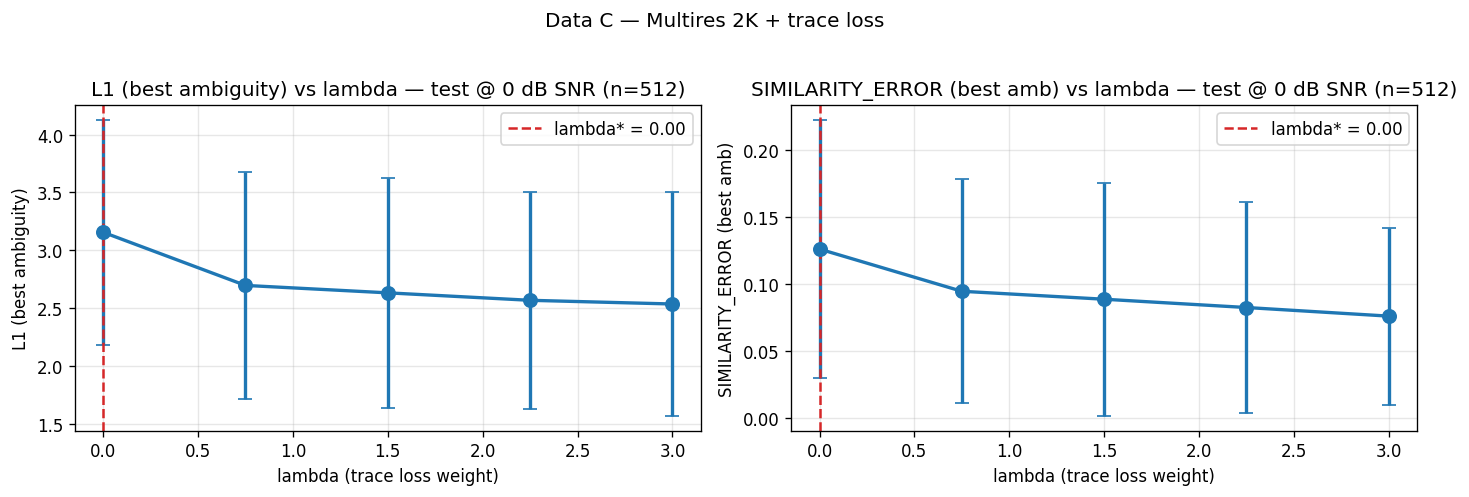

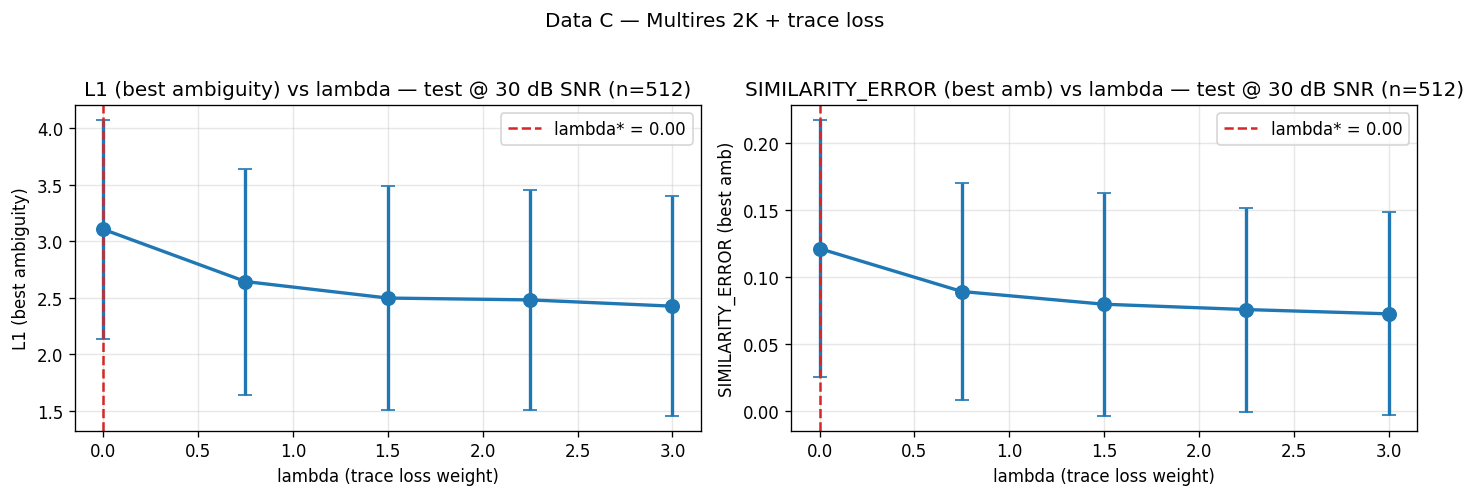

In [1]:
plot_data_c_test_errors_vs_lambda(
    0.0,
    DATA_C_TRACE_EVAL_0DB,
    DATA_C_TRACE_LAM_EVALS,
    lambda_opt=lambda_opt_c,
    n_test=int(eval_trace["n_test"]),
)

plot_data_c_test_errors_vs_lambda(
    30.0,
    DATA_C_TRACE_EVAL_30DB,
    DATA_C_TRACE_LAM_EVALS_30DB,
    lambda_opt=lambda_opt_c,
    n_test=int(eval_trace_30["n_test"]),
)

## 8. Data C — test SNR sweep: λ = 0 vs λ = 3

Best-ambiguity **L1** and **SIMILARITY_ERROR** vs. trace SNR on the 512-pulse test set for **Multires 2K + trace loss** at **λ = 0** and **λ = 3**.

**To view:** scroll to this section (bottom of notebook), then run the code cell below (requires the imports cell at the top: `BENCH`, `N_TEST`, `load_cnn_sweep`, `plot_metric_curves`). PNG copies are also saved under `checkpoints/benchmark/figures/`.

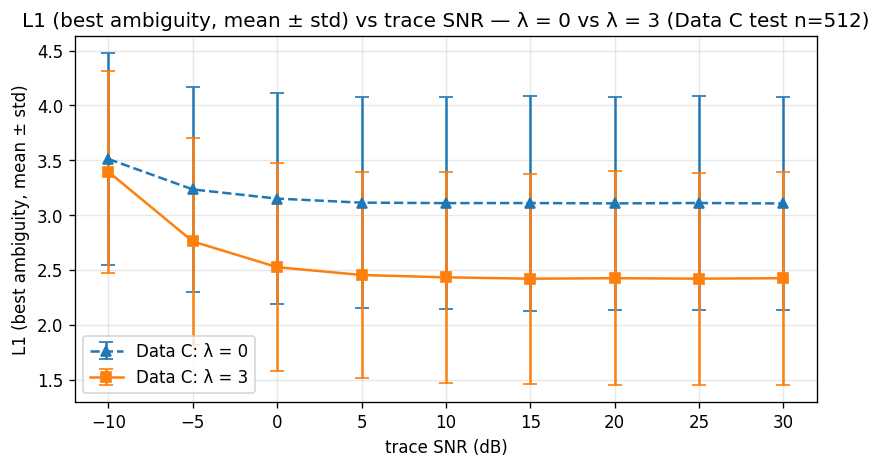

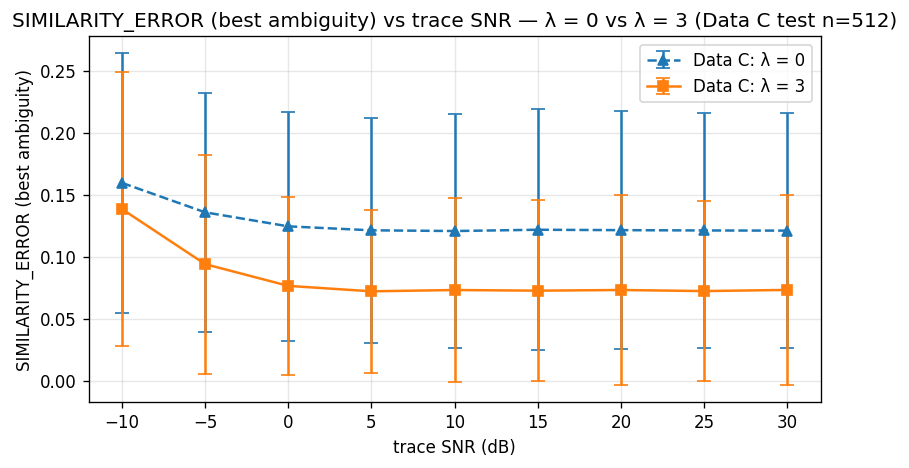

In [1]:
%matplotlib inline

DATA_C_SWEEP_LAM0 = BENCH / "stochastic_data_c_multires_2k_noisy_trace_lambda_baseline_sweep.npz"
DATA_C_SWEEP_LAM3 = BENCH / "stochastic_data_c_multires_2k_trace_lam300_sweep.npz"

assert DATA_C_SWEEP_LAM0.exists(), f"Missing {DATA_C_SWEEP_LAM0}"
assert DATA_C_SWEEP_LAM3.exists(), f"Missing {DATA_C_SWEEP_LAM3}"

sweep_lam0 = load_cnn_sweep(DATA_C_SWEEP_LAM0)
sweep_lam3 = load_cnn_sweep(DATA_C_SWEEP_LAM3)
sweep_lam0.experiment_name = "Data C: λ = 0"
sweep_lam3.experiment_name = "Data C: λ = 3"

curves = [sweep_lam0, sweep_lam3]
snr = sweep_lam0.snr_sweep_db
fmts = ["--^", "-s"]
tag = f"Data C test n={N_TEST}"

def _plot_data_c_snr_metric(attr_m, attr_s, ylabel, title_suffix):
    series = [
        (getattr(r, attr_m), getattr(r, attr_s), fmts[i], r.experiment_name)
        for i, r in enumerate(curves)
    ]
    plot_metric_curves(
        snr,
        series,
        xlabel="trace SNR (dB)",
        ylabel=ylabel,
        title=f"{ylabel} vs trace SNR — {title_suffix} ({tag})",
    )

_plot_data_c_snr_metric(
    "cnn_l1_amb_m",
    "cnn_l1_amb_s",
    "L1 (best ambiguity, mean ± std)",
    "λ = 0 vs λ = 3",
)
_plot_data_c_snr_metric(
    "cnn_sim_amb_m",
    "cnn_sim_amb_s",
    "SIMILARITY_ERROR (best ambiguity)",
    "λ = 0 vs λ = 3",
)

print("Saved:", BENCH / "figures/data_c_snr_lam0_vs_lam3_l1.png")
print("Saved:", BENCH / "figures/data_c_snr_lam0_vs_lam3_sim.png")

## 9. Data C — Multires 2K trained with **trace loss only** (Runs A & B)

Two training runs with the **same trace-only training loss** but **different early-stopping metrics**. Full protocols below. Script: `scripts/run_multires_2k_stochastic_data_c_trace_only.py`.

### 9a. Run A — trace-only loss, early stop on **val pulse L1**

**Script:** `scripts/run_multires_2k_stochastic_data_c_trace_only.py` (default `--early-stop-metric pulse`).

**Data (stochastic Data C):** 2048 train / 200 val / 512 test pulses; `seed=0`; `t_center_std=9.5` fs.

**Model:** Multires 2K (`build_model(..., model_name="multires")`), 64×64 FROG grid.

**Training loss (every batch):**
$$\mathcal{L}_{\mathrm{train}} = \mathrm{L1}_{\mathrm{trace}} / s_{\mathrm{trace}}$$
where $\mathrm{L1}_{\mathrm{trace}} = \sum_{i,j}|I_{\mathrm{pred}} - I_{\mathrm{clean}}|$ on the clean trace, $I_{\mathrm{pred}} = \mathrm{FROG}(E_{\mathrm{pred}})$, and $s_{\mathrm{trace}}$ is the median pulse-L1 / trace-L1 ratio calibrated on 8 training batches. **No pulse L1 term** and no $\lambda$.

**Noise:** AWGN on the input trace; training SNR $\sim \mathcal{U}[0, 30]$ dB per batch.

**Optimization:** Adam, `lr=1e-3`, up to 200 epochs, patience 25.

**Early stopping & checkpoint:** monitored metric is **val pulse L1 @ 15 dB** (200 pulses), *not* the training loss. Best weights = epoch with lowest val pulse L1.

**Result (Run A):** `best_epoch=1`, `stopped_epoch=26` — val pulse L1 never improved after epoch 1 while trace loss kept decreasing; the saved model is essentially untrained for pulse reconstruction.

**Test evaluation (SNR sweep):** 512 held-out test pulses; for each SNR in $\{-10,-5,\ldots,30\}$ dB, add AWGN to the trace, run the CNN, and report **best-ambiguity** L1 and SIMILARITY_ERROR (mean $\pm$ std over pulses). Artifacts: `stochastic_data_c_multires_2k_trace_only.pt`, `_sweep.npz`.

### 9b. Run B — trace-only loss, early stop on **val trace L1**

**Script:** same as Run A with `--early-stop-metric trace --force`.

**Training loss:** identical to Run A ($\mathrm{L1}_{\mathrm{trace}} / s_{\mathrm{trace}}$ only).

**Early stopping & checkpoint:** monitored metric is **val trace L1 / $s_{\mathrm{trace}}$ @ 15 dB** (aligned with the training objective). Val pulse L1 is still logged but not used for stopping.

**Result (Run B):** `best_epoch=97`, `stopped_epoch=122`, `best val trace loss @ 15 dB = 2.339`, `val pulse L1 @ 15 dB = 10.85` at the best epoch.

**Test evaluation:** same SNR sweep protocol as Run A. Artifacts: `stochastic_data_c_multires_2k_trace_only_valtrace.pt`, `_valtrace_sweep.npz`.


In [ ]:
RUN_DATA_C_TRACE_ONLY_TRAIN = False
FORCE_DATA_C_TRACE_ONLY_RETRAIN = False
RUN_DATA_C_TRACE_ONLY_VALTRACE = False
FORCE_DATA_C_TRACE_ONLY_VALTRACE_RETRAIN = False

DATA_C_TRACE_ONLY_CKPT = BENCH / "stochastic_data_c_multires_2k_trace_only.pt"
DATA_C_TRACE_ONLY_META = BENCH / "stochastic_data_c_multires_2k_trace_only_meta.json"
DATA_C_TRACE_ONLY_SWEEP = BENCH / "stochastic_data_c_multires_2k_trace_only_sweep.npz"
DATA_C_TRACE_ONLY_VALTRACE_CKPT = BENCH / "stochastic_data_c_multires_2k_trace_only_valtrace.pt"
DATA_C_TRACE_ONLY_VALTRACE_META = BENCH / "stochastic_data_c_multires_2k_trace_only_valtrace_meta.json"
DATA_C_TRACE_ONLY_VALTRACE_SWEEP = BENCH / "stochastic_data_c_multires_2k_trace_only_valtrace_sweep.npz"
DATA_C_TRACE_ONLY_SCRIPT = SRC / "scripts/run_multires_2k_stochastic_data_c_trace_only.py"

def _run_data_c_trace_only(early_stop_metric, force):
    cmd = [
        sys.executable,
        str(DATA_C_TRACE_ONLY_SCRIPT),
        "--seed", str(SEED),
        "--n-train", str(N_TRAIN),
        "--n-val", str(N_VAL),
        "--n-test", str(N_TEST),
        "--max-epochs", str(MAX_EPOCHS),
        "--patience", str(PATIENCE),
        "--train-snr-min", str(TRAIN_SNR_DB_RANGE[0]),
        "--train-snr-max", str(TRAIN_SNR_DB_RANGE[1]),
        "--val-snr-db", str(VAL_SNR_DB),
        "--early-stop-metric", early_stop_metric,
    ]
    if force:
        cmd.append("--force")
    print("Running:", " ".join(cmd))
    proc = subprocess.run(cmd, cwd=str(SRC))
    if proc.returncode != 0:
        raise RuntimeError(f"Data C trace-only ({early_stop_metric}) failed (exit {proc.returncode})")

if RUN_DATA_C_TRACE_ONLY_TRAIN:
    _run_data_c_trace_only("pulse", FORCE_DATA_C_TRACE_ONLY_RETRAIN)
if RUN_DATA_C_TRACE_ONLY_VALTRACE:
    _run_data_c_trace_only("trace", FORCE_DATA_C_TRACE_ONLY_VALTRACE_RETRAIN)

assert DATA_C_TRACE_ONLY_CKPT.exists(), f"Missing {DATA_C_TRACE_ONLY_CKPT}"
assert DATA_C_TRACE_ONLY_META.exists(), f"Missing {DATA_C_TRACE_ONLY_META}"
assert DATA_C_TRACE_ONLY_SWEEP.exists(), f"Missing {DATA_C_TRACE_ONLY_SWEEP}"
assert DATA_C_TRACE_ONLY_VALTRACE_CKPT.exists(), f"Missing {DATA_C_TRACE_ONLY_VALTRACE_CKPT}"
assert DATA_C_TRACE_ONLY_VALTRACE_META.exists(), f"Missing {DATA_C_TRACE_ONLY_VALTRACE_META}"
assert DATA_C_TRACE_ONLY_VALTRACE_SWEEP.exists(), f"Missing {DATA_C_TRACE_ONLY_VALTRACE_SWEEP}"

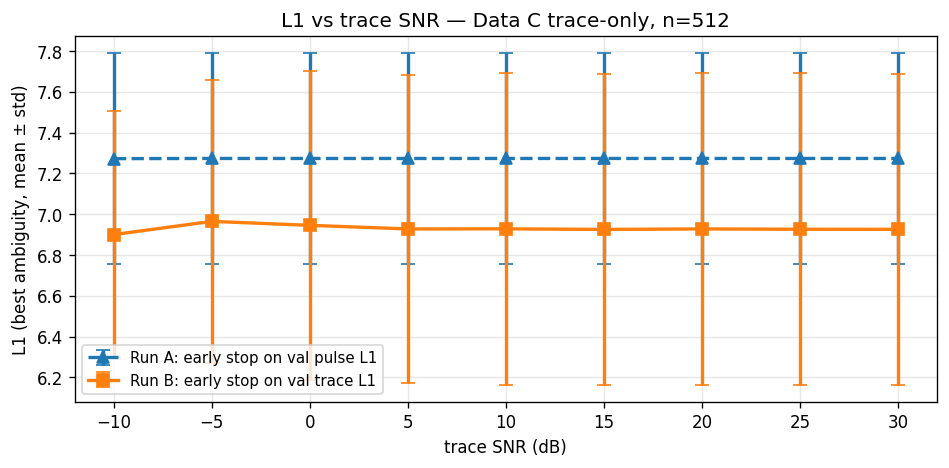

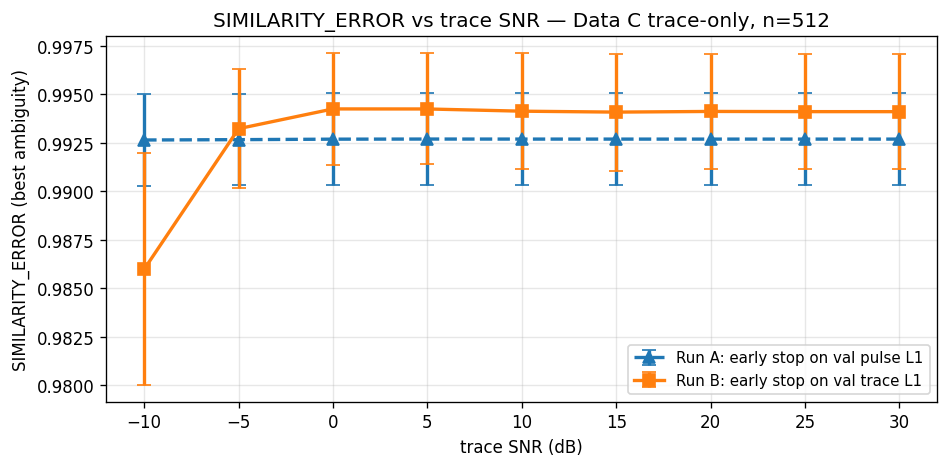

In [1]:
%matplotlib inline

sweep_a = load_cnn_sweep(DATA_C_TRACE_ONLY_SWEEP)
sweep_b = load_cnn_sweep(DATA_C_TRACE_ONLY_VALTRACE_SWEEP)
sweep_a.experiment_name = "Run A: early stop on val pulse L1"
sweep_b.experiment_name = "Run B: early stop on val trace L1"
snr = sweep_a.snr_sweep_db
tag = f"Data C trace-only, n={N_TEST}"

for attr_m, attr_s, ylabel in (
    ("cnn_l1_amb_m", "cnn_l1_amb_s", "L1 (best ambiguity, mean ± std)"),
    ("cnn_sim_amb_m", "cnn_sim_amb_s", "SIMILARITY_ERROR (best ambiguity)"),
):
    plot_metric_curves(
        snr,
        [
            (getattr(sweep_a, attr_m), getattr(sweep_a, attr_s), "--^", sweep_a.experiment_name),
            (getattr(sweep_b, attr_m), getattr(sweep_b, attr_s), "-s", sweep_b.experiment_name),
        ],
        xlabel="trace SNR (dB)",
        ylabel=ylabel,
        title=f"{ylabel} vs trace SNR — {tag}",
    )

## 10. Data C — trace-only Run B: test SNR sweep

Reconstruction error vs. trace SNR for **Run B** (trace-only training; early stop on val trace L1 @ 15 dB).

Run B summary
  best_epoch = 97  stopped_epoch = 122
  best val trace loss @ 15 dB = 2.33907
  val pulse L1 @ best epoch = 10.84879


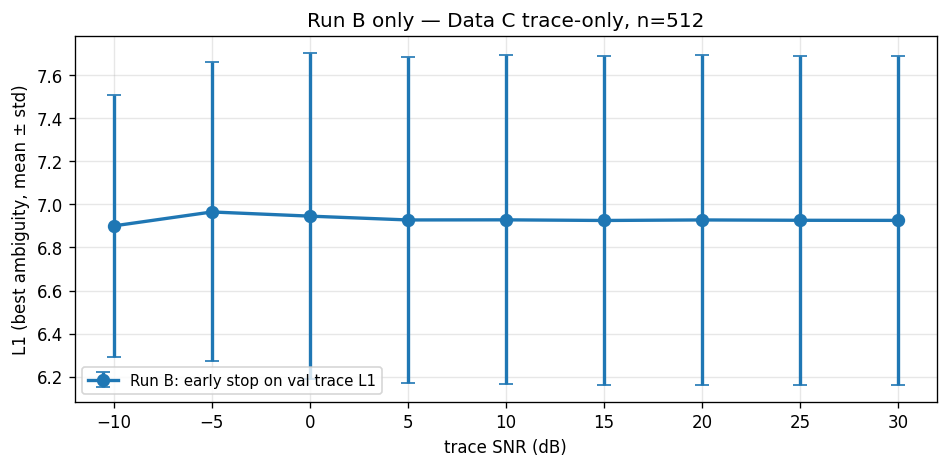

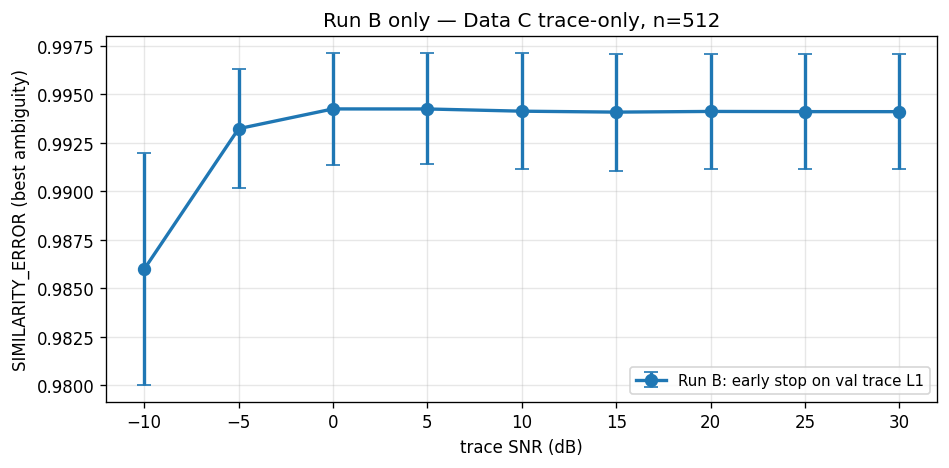

In [1]:
%matplotlib inline

meta_b = json.loads(DATA_C_TRACE_ONLY_VALTRACE_META.read_text(encoding="utf-8"))
print("Run B — trace-only, early stop on val trace L1")
print(f"  best_epoch = {int(meta_b['best_epoch'])}  stopped_epoch = {int(meta_b['stopped_epoch'])}")
print(f"  best val trace loss @ {float(meta_b['val_snr_db']):.0f} dB = {float(meta_b['best_val_trace_loss']):.5f}")
print(f"  val pulse L1 at best epoch = {float(meta_b['best_val_l1']):.5f}")

sweep_b = load_cnn_sweep(DATA_C_TRACE_ONLY_VALTRACE_SWEEP)
sweep_b.experiment_name = "Run B: early stop on val trace L1"
snr = sweep_b.snr_sweep_db
tag = f"Data C trace-only Run B, n={N_TEST}"

for attr_m, attr_s, ylabel in (
    ("cnn_l1_amb_m", "cnn_l1_amb_s", "L1 (best ambiguity, mean ± std)"),
    ("cnn_sim_amb_m", "cnn_sim_amb_s", "SIMILARITY_ERROR (best ambiguity)"),
):
    plot_metric_curves(
        snr,
        [(getattr(sweep_b, attr_m), getattr(sweep_b, attr_s), "o-", sweep_b.experiment_name)],
        xlabel="trace SNR (dB)",
        ylabel=ylabel,
        title=f"{ylabel} vs trace SNR — {tag}",
    )